# Imports, parameters & paths

In [6]:
raw_data_dirs = ['/marmostor/Vaziri/Data/Cadbury/20221016d/SP_SiteB_200umdeep_1p46by1p46mm_2umppix_6p36Hz_59mW/'] # must be a list with 1 or more paths 
fname_must_contain = ''
fname_must_NOT_contain = 'randomstuff'

import numpy as np
import glob
import json
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 900
import os
from skimage import io as skio
import tifffile

save_plane7_only = False
pix_shift_x_parameter = 'calculate' # set to 'calculate' to automatically determine best overlap, or set to a specific value (e.g. 0, for no correction)
Zscore_thresh_discard_edge_pixs_SP = 2.5 #2.5 # when comparing pixels of overlapping edges of two mrois

replace_mov_frames = None # use None for mantaining raw data, or an array where each array[i,0] and array[i,1] are the frames # where the animal started and stopped moving, respectively
#replace_mov_frames = np.array([[160, 210], [810, 860], [1470,1520], [2035,2085]])
#Hershey SiteB replace_mov_frames = np.array([[130, 185], [780, 835], [1440,1495], [2005,2060]])
#Hershey SiteC replace_mov_frames = np.array([[190, 225], [505, 540], [730,770], [1280,1330]])
#Hershey SiteD replace_mov_frames = np.array([[20, 55], [150, 185], [845,895], [1200,1235]])

pixel_crop_all = 0 # overrides other crops
pixel_crop_top = 0
pixel_crop_bottom = 0
pixel_crop_left = 0
pixel_crop_right = 0
pixel_crop_vector = [pixel_crop_all, pixel_crop_top, pixel_crop_bottom, pixel_crop_left, pixel_crop_right]

paths_for_reshape_in = []
paths_for_reshape_out = []


for dir_i in raw_data_dirs:
    tif_paths = sorted(glob.glob(dir_i + '/**/*.tif', recursive = True))
    for tif_path in tif_paths:
        if fname_must_contain in tif_path and fname_must_NOT_contain not in tif_path:
            path_for_reshape_in = tif_path.replace('\\','/')
            path_for_reshape_out = path_for_reshape_in.replace('Data','Analysis')
            if save_plane7_only:
                path_for_reshape_out = path_for_reshape_out[:-4] + '_Reshaped_plane7.tif'
            else:
                path_for_reshape_out = path_for_reshape_out[:-4] + '_Reshaped.tif'
            
            paths_for_reshape_in.append(path_for_reshape_in)
            paths_for_reshape_out.append(path_for_reshape_out)

print(paths_for_reshape_in)
print(paths_for_reshape_out)
            

['/marmostor/Vaziri/Data/Cadbury/20221016d/SP_SiteB_200umdeep_1p46by1p46mm_2umppix_6p36Hz_59mW/SP_SiteB_200umdeep_1p46by1p46mm_2umppix_6p36Hz_59mW_00001.tif']
['/marmostor/Vaziri/Analysis/Cadbury/20221016d/SP_SiteB_200umdeep_1p46by1p46mm_2umppix_6p36Hz_59mW/SP_SiteB_200umdeep_1p46by1p46mm_2umppix_6p36Hz_59mW_00001_Reshaped.tif']


# Reshaping

Define main function and helpers. Main function is: main_tif_reshape(paths_for_reshape_in, paths_for_reshape_out)

In [7]:
### Main function

def main_tif_reshape(paths_for_reshape_in, 
                     paths_for_reshape_out, 
                     replace_mov_frames = None, 
                     pix_shift_x_parameter = 'calculate',
                     Zscore_thresh_discard_edge_pixs_SP = 2, 
                     pixel_crop_vector = [0, 0, 0, 0, 0],
                     save_plane7_only = False):
    
    for idx in range(len(paths_for_reshape_in)):

        print('---------------------------------------------------')
        print('---------------------------------------------------')
        print('---------------------------------------------------')


        tif_path = paths_for_reshape_in[idx]
        print('Started working on: ' + tif_path)

        # Only calculate pix_shift_x for roi stitching if this is the first file
        if '00001.tif' in tif_path:
            pix_shift_x = pix_shift_x_parameter

        # Determine if it is a single-plane, Max15, or Max30 recording
        if 'SP' in tif_path:
            n_chans = 1
            chans_order = np.array([0])
            Zscore_thresh_discard_edge_pixs = Zscore_thresh_discard_edge_pixs_SP
        elif 'Max15' in tif_path:
            n_chans = 15
            chans_order = np.array([ 1,  3,  4,  5,  6,  7,  2,  8,  9, 10, 11, 12, 13, 14, 15]) - 1
            Zscore_thresh_discard_edge_pixs = -1 # For some reason, it't not necessary for Maximum
        elif 'Max30' in tif_path:
            n_chans = 30
            chans_order = np.array([ 1,  5,  6,  7,  8,  9,  2, 10, 11, 12, 13, 14, 15, 16, 17,
                                        3, 18, 19, 20, 21, 22, 23,  4, 24, 25, 26, 27, 28, 29, 30]) - 1
            Zscore_thresh_discard_edge_pixs = -1
        else:
            n_chans = int(input('Check filename... Number of planes?'))
        print('Number of planes: ' + str(n_chans))

        print('Loading (expect warning if multi-file recording)... ')
        tiff_file = skio.imread(tif_path)

        #Some initial reshaping is required for Maximum recordings
        print('Reshaping...')
        if n_chans > 1: 

            tiff_file = np.reshape(tiff_file, ( int(tiff_file.shape[0]/n_chans), n_chans,tiff_file.shape[1],tiff_file.shape[2]), order='A') # warnings are expected if the recording is split into many files or incomplete
            if save_plane7_only:
                tiff_file = tiff_file[:,6,:,:]
                tiff_file = np.expand_dims(tiff_file,1)
                chans_order = np.array([0])
                n_chans = 1
        else:
            tiff_file = np.expand_dims(tiff_file,1)
        
        # ROI stitching
        print('Stitching ROIs...')
        tiff_file = tiff_file[:,chans_order]
        rois = get_meso_rois(tif_path)
        tiff_file_stitched = []
        for chan_i in range(n_chans):

            if len(rois) > 1:
                ims = split_rois_from_tif(tiff_file,rois,ch_id=chan_i)
                stitched, _, _, pix_shift_x = stitch_rois_fast(ims,rois,mean_img = False, pix_shift_x = pix_shift_x, Zscore_thresh_discard_edge_pixs = Zscore_thresh_discard_edge_pixs)
                if chan_i == 0:
                    print('pix_shift_x is ' + str(pix_shift_x))
            else:
                stitched = tiff_file[:,chan_i,:,:]

            if replace_mov_frames is not None:
                average_frame = np.mean(stitched[5:15], axis = 0)
                for i in range(len(replace_mov_frames_idx)):
                    for f in range(replace_mov_frames_idx[i,0],replace_mov_frames_idx[i,1]):
                        if f > 0 and f < 20:
                            print('Was not expecting the movie to start with movement!! Please redefine with what you are replacing the frames with motion (i.e. average_frame)')
                        stitched[f] = average_frame
            
            stitched = crop_sides(stitched, pixel_crop_vector = pixel_crop_vector)
            tiff_file_stitched.append(stitched)

        tiff_file = np.zeros((stitched.shape[0], n_chans, stitched.shape[1], stitched.shape[2]),  dtype = np.int16)
        mean_imgs = np.zeros((n_chans, stitched.shape[1], stitched.shape[2]),  dtype = np.int16)
        for chan_i in range(n_chans):
            tiff_file[:,chan_i] = tiff_file_stitched[chan_i]
            mean_imgs[chan_i] = (np.mean(tiff_file[:,chan_i], axis = 0))
        del tiff_file_stitched

        # Create saving directory
        save_dir = os.path.dirname(paths_for_reshape_out[idx])  
        if not os.path.isdir(save_dir):
            os.makedirs(save_dir)

        # Display and save figure with average frame
        print('Calculating and displaying average frame...')
        fig = plt.figure(dpi=900)
        mean_imgs_horizontal = np.concatenate(mean_imgs[:], axis = 1)
        mean_imgs_horizontal_20pct = np.percentile(mean_imgs_horizontal,20)
        mean_imgs_horizontal_99pct = np.percentile(mean_imgs_horizontal,99)
        plt.imshow(mean_imgs_horizontal, cmap='gray', vmin = mean_imgs_horizontal_20pct, vmax = mean_imgs_horizontal_99pct)        
        plt.title(paths_for_reshape_out[idx],fontsize=4)
        plt.xticks(fontsize=4)
        plt.yticks(fontsize=4)
        fig.tight_layout()
        plt.show()
        print('Saving average frame...')
        fig.savefig(paths_for_reshape_out[idx][:-4] + '.png',bbox_inches='tight')

        print('Saving recording...')

        tiff_file = np.reshape(tiff_file, ( tiff_file.shape[0]*tiff_file.shape[1], tiff_file.shape[2], tiff_file.shape[3]))
        tifffile.imwrite(paths_for_reshape_out[idx], tiff_file)

        print('Saved')
    print('Done')

    
### Helpers

def pad(data, pad_multiple = 16):
    if pad_multiple > 0:
        final_size_vertical = int(np.ceil(data.shape[1] / pad_multiple)) * pad_multiple
        final_size_horizontal = int(np.ceil(data.shape[2] / pad_multiple)) * pad_multiple
        top_pad     = int(np.ceil ((final_size_vertical - data.shape[1]) / 2))
        bottom_pad  = int(np.floor((final_size_vertical - data.shape[1]) / 2))
        left_pad    = int(np.ceil ((final_size_horizontal - data.shape[2]) / 2))
        right_pad   = int(np.floor((final_size_horizontal - data.shape[2]) / 2))
        padded = np.pad(data,[(0,0), (top_pad, bottom_pad), (left_pad, right_pad)])
        return padded
    else:
        return data

def crop_sides(data, pixel_crop_vector = [0, 0, 0, 0, 0]):
    if pixel_crop_vector[0] > 0:
        pixel_crop_top, pixel_crop_bottom, pixel_crop_left, pixel_crop_right = pixel_crop_vector[0], pixel_crop_vector[0], pixel_crop_vector[0], pixel_crop_vector[0]
    else:
        pixel_crop_top, pixel_crop_bottom, pixel_crop_left, pixel_crop_right = pixel_crop_vector[1:]
    data = data[:, pixel_crop_top:(-1-pixel_crop_bottom), pixel_crop_left:(-1-pixel_crop_right)]
    return data

def get_meso_rois(tif_path):
    tf = tifffile.TiffFile(tif_path)
    artists_json = tf.pages[0].tags["Artist"].value

    si_rois = json.loads(artists_json)['RoiGroups']['imagingRoiGroup']['rois']
    if type(si_rois) != dict:
        rois = []
        for roi in si_rois:
            if type(roi['scanfields']) != list:
                scanfield = roi['scanfields']
            else: 
                scanfield = roi['scanfields'][np.where(np.array(roi['zs'])==0)[0][0]]
    
            roi_dict = {}
            roi_dict['uid'] = scanfield['roiUuid']
            roi_dict['center'] = np.array(scanfield['centerXY'])
            roi_dict['sizeXY'] = np.array(scanfield['sizeXY'])
            roi_dict['pixXY'] = np.array(scanfield['pixelResolutionXY'])
            
            rois.append(roi_dict)
    else:
        scanfield = si_rois['scanfields']
        roi_dict = {}
        roi_dict['uid'] = scanfield['roiUuid']
        roi_dict['center'] = np.array(scanfield['centerXY'])
        roi_dict['sizeXY'] = np.array(scanfield['sizeXY'])
        roi_dict['pixXY'] = np.array(scanfield['pixelResolutionXY'])
        rois = [roi_dict]
    return rois

def split_rois_from_tif(im, rois, ch_id = 0, return_coords=False):
    nt, nplanes, ny, nx = im.shape
    n_rois = len(rois)
    ys = np.array([roi['pixXY'][1] for roi in rois])
    n_buff = (ny - ys.sum())//(len(rois)-1)
    
    split_ims = []
    coords = []
    y_start = 0
    for i in range(n_rois):
        ny = ys[i]
        split_im = im[:, ch_id, y_start:y_start+ny]
        coord = np.meshgrid(np.arange(y_start, y_start+ny), np.arange(0,im.shape[-1]))
        split_ims.append(split_im)
        y_start += ny + n_buff
        coords.append(coord)
    if return_coords: return split_ims, coords
    return split_ims

def stitch_rois_fast(ims, rois, mean_img=False, pix_shift_x = 'calculate', Zscore_thresh_discard_edge_pixs = -1):
    
    # sort the ROIs from left to right
    centers = np.array([r['center'] for r in rois])
    x_sorted = np.argsort(centers[:,0])

    ims = [ims[i] for i in x_sorted]
    rois = [rois[i] for i in x_sorted]
    
    if mean_img:
        n_t = 1
    else:
        n_t = ims[0].shape[0]

    centers = np.array([r['center'] for r in rois])
    sizes_pix = np.array([im.shape[1:][::-1] for im in ims])

    sizes = np.array([r['sizeXY'] for r in rois])
    corners = centers - sizes/2
    n_rois = len(rois)

    # X is the fast axis along the resonant scanner line direction, Y is orthogonal slow axis
    # For a typical strip, x extent is small and y extent is large

    # maximim and minimum x/y coordinates in SI units (not pixels, also strangely not um)
    xmin, xmax = corners[:,0].min(),(corners[:,0] + sizes[:,0]).max()
    ymin, ymax = corners[:,1].min(),(corners[:,1] + sizes[:,1]).max()

    # calculate pixel sizes (relative to weird SI units)
    pixel_sizes = sizes/sizes_pix
    psize_y = np.mean(pixel_sizes[:,1])
    psize_x = np.mean(pixel_sizes[:,0])
    assert np.product(np.isclose(pixel_sizes[:,1]-psize_y, 0)), "Y pixels not uniform"
    assert np.product(np.isclose(pixel_sizes[:,0]-psize_x, 0)), "X pixels not uniform"

    # SI unit coordinates of each pixel of the full image
    full_xs = np.arange(xmin,xmax, psize_x)
    full_ys = np.arange(ymin,ymax, psize_y)

    # calculate the starting pixel for each of the ROIs when placing them into full image
    roi_start_pix_x = []
    roi_start_pix_y = []
    for roi_idx in range(n_rois):
        x_corner = corners[roi_idx,0]
        y_corner = corners[roi_idx, 1]

        closest_x_idx = np.argmin(np.abs(full_xs-x_corner))
        roi_start_pix_x.append(closest_x_idx)
        closest_x = full_xs[closest_x_idx]
        if not np.isclose(closest_x, x_corner):
            print("ROI %d x does not fit perfectly into image, corner is %.4f but closest available is %.4f" %\
                  (roi_idx, closest_x, x_corner))
            
        closest_y_idx = np.argmin(np.abs(full_ys-y_corner))
        roi_start_pix_y.append(closest_y_idx)
        closest_y = full_ys[closest_y_idx]
        if not np.isclose(closest_y, y_corner):
            print("ROI %d y does not fit perfectly into image, corner is %.4f but closest available is %.4f" %\
                  (roi_idx, closest_y, y_corner))
             
        if not np.isclose(closest_y, y_corner):
            MROIs_aligned = False
        else:
            MROIs_aligned = True
            if len(full_xs) == np.sum(sizes_pix[:,0]) + 1: #sometimes an extra pixel is added because of pixel_size rounding
                full_xs = full_xs[:-1]
            
            elif len(full_xs) != np.sum(sizes_pix[:,0]): # and sometimes it is completely off... so we just take the number of pixels and ignore the resolution
                full_xs = np.linspace(xmin,xmax, np.sum(sizes_pix[:,0]))
            
            if len(full_ys) == int(np.mean(sizes_pix[:,1])) + 1: #sometimes an extra pixel is added because of pixel_size rounding
                full_ys = full_ys[:-1]
            
    if not MROIs_aligned:
        pix_shift_x = 0
    else:
        width_strip = 7 #width of moving strip for calculating optimal shift between MROIs
        if pix_shift_x == 'calculate':
            pix_shift_x = []
            for roi_idx in range(n_rois):
                roi_x_start = roi_start_pix_x[roi_idx]
                
                if roi_idx > 0:
                    previous_roi_x_end = roi_start_pix_x[roi_idx -1] + sizes_pix[roi_idx -1][0]
                    if abs(roi_x_start - previous_roi_x_end) < 20:
                        first_cols_mean_this_ims = ims[roi_idx][:,:,:width_strip].mean(axis=0)
                        mean_previous_ims = ims[roi_idx-1].mean(axis=0)
                        dissimilarity = []
                        for shift in range(25):
                            temp_last_cols_mean_last_im = mean_previous_ims[:,-width_strip-shift-1:-shift-1]
                            this_dissimilarity = sum(sum(abs((temp_last_cols_mean_last_im - first_cols_mean_this_ims)**1)))
                            dissimilarity.append(this_dissimilarity)
                        pix_shift_x.append(np.argmin(dissimilarity) + np.floor(width_strip/2))
            pix_shift_x = round(np.median(pix_shift_x)) + width_strip
        
    full_image = np.zeros((n_t, len(full_ys), len(full_xs)  - pix_shift_x * (n_rois-1) ), dtype = np.int16)
    stitch_rois_fast_helper(full_image, ims, np.array(roi_start_pix_x), np.array(roi_start_pix_y), sizes_pix, mean_img, pix_shift_x, Zscore_thresh_discard_edge_pixs)

    return full_image, psize_x, psize_y, pix_shift_x

def stitch_rois_fast_helper(full_image, ims, roi_start_pix_x, roi_start_pix_y, sizes_pix, mean_img, pix_shift_x, Zscore_thresh_discard_edge_pixs):
    full_image[:] = 0
    n_rois = len(ims)

    # place each ROI into full image
    for roi_idx in range(n_rois):
        roi_x_start = roi_start_pix_x[roi_idx] - roi_idx * pix_shift_x
        roi_y_start = roi_start_pix_y[roi_idx]
        roi_x_end = roi_x_start + sizes_pix[roi_idx][0] 
        roi_y_end = roi_y_start + sizes_pix[roi_idx][1]
        
        if mean_img:
            return
            full_image[0, roi_y_start:roi_y_end, roi_x_start:roi_x_end] = ims[roi_idx].mean(axis=0)
        else:
            full_image[:,roi_y_start:roi_y_end, roi_x_start:roi_x_end] = ims[roi_idx]
            
            if roi_idx > 0 and pix_shift_x > 0:
            
                for pix in range(pix_shift_x):
                    pix_strip_left  = np.copy(ims[roi_idx-1][:,:,-pix_shift_x+pix] )
                    pix_strip_right = np.copy(ims[roi_idx][:,:,pix])
                    
                    if roi_start_pix_y[roi_idx] == roi_start_pix_y[roi_idx-1]: #check if the 2 ROIs are at the same Y position
                        same_y = True
                    elif roi_start_pix_y[roi_idx] < roi_start_pix_y[roi_idx-1]: # Right ROI starts closer to the top
                        diff_y_pix = roi_start_pix_y[roi_idx - 1] - roi_start_pix_y[roi_idx]
                        pix_strip_left = np.concatenate([pix_strip_right[:,:diff_y_pix], pix_strip_left], axis = 1)
                        pix_strip_right = np.concatenate([pix_strip_right, pix_strip_left[:,-diff_y_pix:]], axis = 1)
                        same_y = False
                    elif roi_start_pix_y[roi_idx] > roi_start_pix_y[roi_idx-1]: # Right ROI starts closer to the bottom
                        diff_y_pix = roi_start_pix_y[roi_idx] - roi_start_pix_y[roi_idx - 1]
                        pix_strip_right = np.concatenate([pix_strip_left[:,:diff_y_pix], pix_strip_right], axis = 1)
                        pix_strip_left = np.concatenate([pix_strip_left, pix_strip_right[:,-diff_y_pix:]], axis = 1)
                        same_y = False
                    
                    pix_strips_two_images = np.stack((pix_strip_left, pix_strip_right))
                    pix_strips_two_images_diff = np.abs(pix_strips_two_images[0] - pix_strips_two_images[1])
                    pix_strips_two_images_max = np.max(pix_strips_two_images, axis=0)
                    
                    #e.g. if there are 8 pixels of overlap, then pixel 1 = 8/9 of leftROI and 1/9 of rightROI
                    pix_strip_average = np.round((1 - (pix+1)/(pix_shift_x+1)) * pix_strips_two_images[0] +  (pix+1)/(pix_shift_x+1) * pix_strips_two_images[1])
                    
                    if Zscore_thresh_discard_edge_pixs >= 0:
                        im_std = np.std(ims[roi_idx][:,:,pix_shift_x + 5: pix_shift_x + 15]) # for stitching, take SD of image region netch to the seam
                        pix_strip_average [pix_strips_two_images_diff > Zscore_thresh_discard_edge_pixs*im_std] = pix_strips_two_images_max [pix_strips_two_images_diff > Zscore_thresh_discard_edge_pixs*im_std]
                    
                    pix_strip = pix_strip_average
                    if same_y:
                        full_image[:, roi_y_start:roi_y_end, roi_x_start + pix] = pix_strip
                    else:
                        full_image[:, min([roi_start_pix_y[roi_idx],roi_start_pix_y[roi_idx-1]]):
                                      max([roi_start_pix_y[roi_idx] + sizes_pix[roi_idx][1], roi_start_pix_y[roi_idx-1] + sizes_pix[roi_idx-1][1]]),
                                      roi_x_start + pix] = pix_strip
                    
    return

Reshape tifs

---------------------------------------------------
---------------------------------------------------
---------------------------------------------------
Started working on: /marmostor/Vaziri/Data/Cadbury/20221016d/SP_SiteB_200umdeep_1p46by1p46mm_2umppix_6p36Hz_59mW/SP_SiteB_200umdeep_1p46by1p46mm_2umppix_6p36Hz_59mW_00001.tif
Number of planes: 1
Loading (expect warning if multi-file recording)... 
Reshaping...
Stitching ROIs...
pix_shift_x is 15
Calculating and displaying average frame...


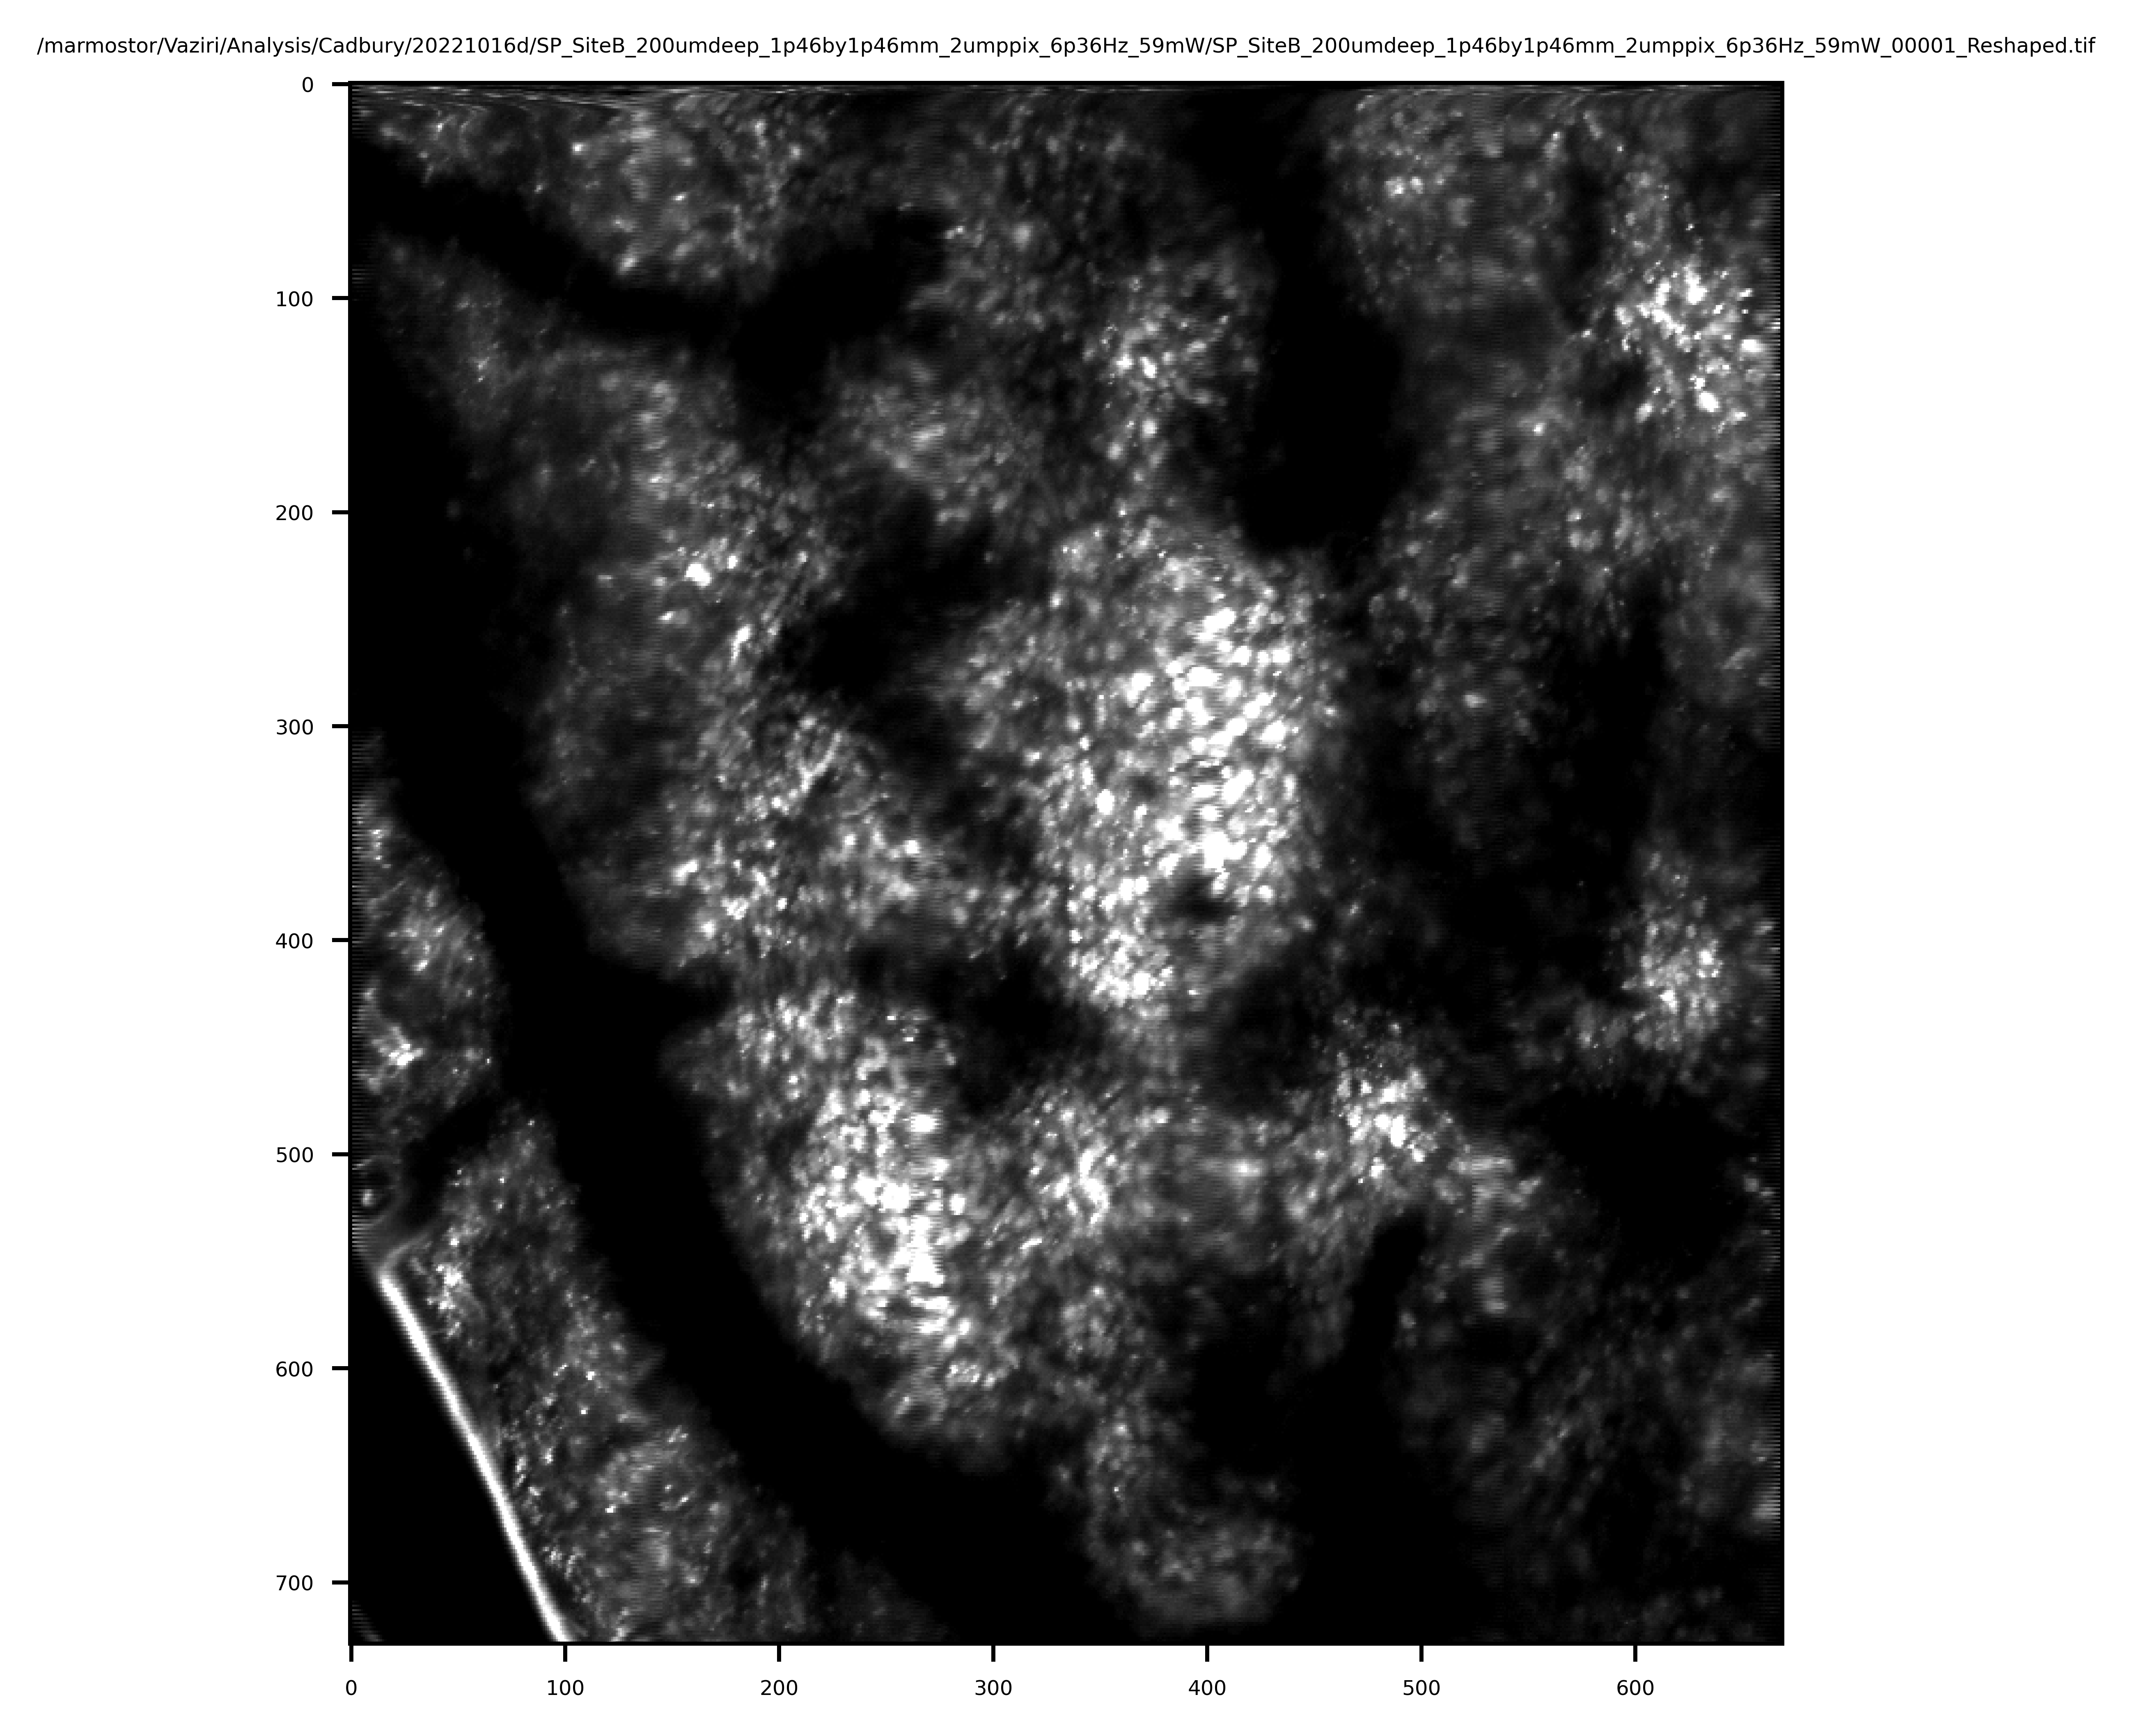

Saving average frame...
Saving recording...
Saved
Done


In [8]:
main_tif_reshape(paths_for_reshape_in = paths_for_reshape_in, 
                 paths_for_reshape_out = paths_for_reshape_out, 
                 replace_mov_frames = replace_mov_frames, 
                 pix_shift_x_parameter = pix_shift_x_parameter, 
                 Zscore_thresh_discard_edge_pixs_SP = Zscore_thresh_discard_edge_pixs_SP,
                 pixel_crop_vector = pixel_crop_vector,
                 save_plane7_only = save_plane7_only)

# Preparing data for Deepinterpolation

In [2]:
def find_paths_planes_suite2p(suite2p_path):
    paths_planes_not_ordered = glob.glob(suite2p_path + '/**/*.tif', recursive = True)
    paths_planes = []
    for plane_i in range(30):
        fname_must_contain = 'plane' + str(plane_i) + '\\'
        fname_must_NOT_contain = 'nothinginparticular'
        for tif_path in paths_planes_not_ordered:
            if fname_must_contain in tif_path and fname_must_NOT_contain not in tif_path:
                paths_planes.append(tif_path)
    return paths_planes



In [3]:
main_folders = []
for path in paths_for_reshape_out:
    this_main_folder = os.path.dirname(paths_for_reshape_out[0])
    if this_main_folder not in main_folders:
        main_folders.append(this_main_folder)
        
main_folders

['F:/Santiago/Analysis/Coconut/20221224d/SP_300umdeep_1p7by2mm_3umppix_8p74Hz_50mW']

In [4]:
paths_planes = find_paths_planes_suite2p(main_folders[0])
paths_planes

['F:/Santiago/Analysis/Coconut/20221224d/SP_300umdeep_1p7by2mm_3umppix_8p74Hz_50mW\\suite2p\\plane0\\reg_tif\\file000_chan0.tif',
 'F:/Santiago/Analysis/Coconut/20221224d/SP_300umdeep_1p7by2mm_3umppix_8p74Hz_50mW\\suite2p\\plane0\\reg_tif\\file5000_chan0.tif']

#### Merging different planes into a single file... (for trying multiplane deepinterpolation)

In [ ]:
# This assumes 1 tif file per plane

def process_tiffs(paths_tifs, 
                  concatenate_or_volume, 
                  extend_one_plane = False,
                  frames_per_tif = -1,  
                  pad_multiple = 0,
                  pixel_crop_vector = [0, 0, 0, 0, 0]):
    
    
    tif_files = []
    n_tifs = len(paths_tifs)
    for idx in range(n_tifs): 
        tif_path = paths_tifs[idx] 
        print('Working on: ' + tif_path)
        tif = tifffile.TiffFile(tif_path)
        tif_stack = tifffile.imread(tif_path, key=range(len(tif.pages)))
        tif_stack = crop_sides(tif_stack, pixel_crop_all = pixel_crop_all, pixel_crop_top = pixel_crop_top, pixel_crop_bottom = pixel_crop_bottom, pixel_crop_left = pixel_crop_left, pixel_crop_right = pixel_crop_right)
        tif_stack = pad(tif_stack, pad_multiple = pad_multiple)

        if idx == 0: #Initialize numpy array:
            shape_tif = tif_stack.shape
            if frames_per_tif == -1:
                frames_per_tif = shape_tif[0]

            if concatenate_or_volume == 'concatenate':
                data = np.zeros((frames_per_tif * n_tifs, shape_tif[1], shape_tif[2]), dtype = np.int16)
            elif concatenate_or_volume == 'volume':
                if extend_one_plane:
                    data = np.zeros((frames_per_tif, shape_tif[1], shape_tif[2], n_tifs + 1), dtype = np.int16)
                else: 
                    data = np.zeros((frames_per_tif, shape_tif[1], shape_tif[2], n_tifs), dtype = np.int16)
            else:
                raise Exception('concatenate_or_volume must be set to one of those options')
                
        if concatenate_or_volume == 'concatenate':
            data[frames_per_tif*idx : frames_per_tif*(idx+1), :, :] = tif_stack[:frames_per_tif]
        elif concatenate_or_volume == 'volume':        
            data[:, :, :, idx] = tif_stack[:frames_per_tif]

    return data

In [4]:
data = process_tiffs(paths_planes, 
                     frames_per_tif = -1, 
                     concatenate_or_volume = 'concatenate', 
                     extend_one_plane = False,
                     pixel_crop_vector = [0,0,0,0,0], 
                     pad_multiple = 16)


Working on: F:\Santiago\Analysis\Cadbury\20221016d\Max15_SiteB_300umdeep_1p46by1p46mm_2umppix_6p36Hz_100pct\suite2p\plane2\reg_tif\file000_chan0.tif


In [5]:
path_tif_out = r'F:\Santiago\Analysis\Cadbury\20221016d\SP_SiteB_200umdeep_1p46by1p46mm_2umppix_6p36Hz_59mW/MC.tif'
path_tif_out = r'F:\Santiago\Analysis\Cadbury\20221016d\Max15_SiteB_300umdeep_1p46by1p46mm_2umppix_6p36Hz_100pct\suite2p\plane2\reg_tif/MC.tif'

print(path_tif_out)
tifffile.imwrite(path_tif_out, data)
data.shape

F:\Santiago\Analysis\Cadbury\20221016d\Max15_SiteB_300umdeep_1p46by1p46mm_2umppix_6p36Hz_100pct\suite2p\plane2\reg_tif/MC.tif


(2660, 704, 672)

In [6]:
data = []

#### Exporting Suite2p single-page tifs >> DeepInt (if not preprocessing tiffs)

In [30]:
import tifffile
def format_suite2p_stack(filename, 
                         pixel_crop_vector = [0,0,0,0,0], 
                         pad_multiple = 0):
    
    tif = tifffile.TiffFile(filename)
    tif_stack = tifffile.imread(filename, key=range(len(tif.pages)))
    tif_stack = crop_sides(tif_stack, pixel_crop_vector)
    tif_stack = pad(tif_stack, pad_multiple)
    tifffile.imwrite(filename, tif_stack)

for filename in paths_planes:
    format_suite2p_stack(filename, 
                         pixel_crop_vector = [0,4,0,4,4], 
                         pad_multiple = 16)

# DeepInt

In [2]:
train_paths = ['F:/Santiago/Analysis/Coconut/20221224d/SP_300umdeep_1p7by2mm_3umppix_8p74Hz_50mW\\suite2p\\plane0\\reg_tif\\file000_chan0.tif', 'F:/Santiago/Analysis/Coconut/20221224d/SP_300umdeep_1p7by2mm_3umppix_8p74Hz_50mW\\suite2p\\plane0\\reg_tif\\file5000_chan0.tif'] # paths_planes

import deepinterpolation as de
import os, glob
from deepinterpolation.generic import JsonSaver, ClassLoader # If this fails, see: https://github.com/conda/conda/issues/8273
import datetime
import tensorflow as tf

print(train_paths)
from random import shuffle
shuffle(train_paths)

if len(train_paths) > 20: 
    train_paths = train_paths[10:] # choose files for training dataset
    valid_paths = train_paths[:10] # choose files for validation dataset
else: 
    valid_paths = train_paths

    
now = datetime.datetime.now()
run_uid = now.strftime("%Y_%m_%d_%H_%M")

training_param = {}
network_param = {}
generator_test_param = {}

steps_per_epoch = 1000  #If it is not calculating the loss, try reducing this

generator_param_list = []
            
for indiv_path in train_paths:
    generator_param = {}
    generator_param["type"] = "generator"
    generator_param["name"] = "SingleTifGenerator"
    generator_param["pre_post_frame"] = 8 # it should depend on frame rate and GECI
    generator_param["train_path"] = indiv_path
    generator_param["batch_size"] = 1 # decrease if run out of memory
    generator_param["start_frame"] = 100
    generator_param["end_frame"] = -1
    generator_param["pre_post_omission"] = 0 # Number of frame omitted before and after the predicted frame
    generator_param["randomize"] = 1
    generator_param["steps_per_epoch"] = steps_per_epoch

    generator_param_list.append(generator_param)
    
test_generator_param_list = []
for indiv_path in valid_paths:
    generator_param = {}
    generator_param["type"] = "generator"
    generator_param["name"] = "SingleTifGenerator"
    generator_param["pre_post_frame"] = 8
    generator_param["train_path"] = indiv_path
    generator_param["batch_size"] = 1
    generator_param["start_frame"] = 0
    generator_param["end_frame"] = 99    
    generator_param["pre_post_omission"] = 0  
    generator_param["randomize"] = 1
    generator_param["steps_per_epoch"] = -1 # epoch is not relevant for validation... may crash if not set to 1
    
    test_generator_param_list.append(generator_param)

network_param["type"] = "network"
network_param["name"] = "unet_single_1024"

training_param["type"] = "trainer"
training_param["name"] = "core_trainer"
training_param["run_uid"] = run_uid
training_param["batch_size"] = generator_param["batch_size"]
training_param["steps_per_epoch"] = steps_per_epoch
training_param["period_save"] = 2 # network model is saved during training every period_save epochs
training_param["nb_gpus"] = 1
training_param["nb_times_through_data"] = 5 # if you want to cycle through the entire data. Too many iterations will cause noise overfitting
training_param["learning_rate"] = 0.0002 # 0.0001
training_param["pre_post_frame"] = generator_param["pre_post_frame"]
training_param["apply_learning_decay"] = 1
training_param["initial_learning_rate"] = 0.0002 # 0.0001
training_param["epochs_drop"] = 10 # 10
training_param["loss"] = "mean_squared_error"

training_param["nb_workers"] = 1  # this is to enable multiple threads for data generator loading. Useful when this is slower than training

training_param["caching_validation"] = False # prevents out of memory errors from loading whole validation set

# Set model name
training_param["model_string"] = (
    network_param["name"]
    + "_"
    + training_param["run_uid"]
)

jobdir = ( 
    os.path.dirname(train_paths[0])
    + "/"
    + training_param["model_string"]
)
training_param["output_dir"] = jobdir

try:
    os.mkdir(jobdir)
except:
    print("folder already exists")

path_training = os.path.join(jobdir, "training.json")
json_obj = JsonSaver(training_param)
json_obj.save_json(path_training)

list_train_generator = []
for local_index, indiv_generator in enumerate(generator_param_list):
    path_generator = os.path.join(
        jobdir, "generator" + str(local_index) + ".json")
    json_obj = JsonSaver(indiv_generator)
    json_obj.save_json(path_generator)
    generator_obj = ClassLoader(path_generator)
    train_generator = generator_obj.find_and_build()(path_generator)
    list_train_generator.append(train_generator)

list_test_generator = []
for local_index, indiv_generator in enumerate(test_generator_param_list):
    path_generator = os.path.join(
        jobdir, "test_generator" + str(local_index) + ".json")
    json_obj = JsonSaver(indiv_generator)
    json_obj.save_json(path_generator)
    generator_obj = ClassLoader(path_generator)
    train_generator = generator_obj.find_and_build()(path_generator)
    list_test_generator.append(train_generator)

global_test_generator = de.generator_collection.CollectorGenerator(
    list_test_generator
)

path_network = os.path.join(jobdir, "network.json")
json_obj = JsonSaver(network_param)
json_obj.save_json(path_network)

network_obj = ClassLoader(path_network)
trainer_obj = ClassLoader(path_training)

network_callback = network_obj.find_and_build()(path_network)

global_train_generator = de.generator_collection.CollectorGenerator(
    list_train_generator
)

training_class = trainer_obj.find_and_build()(
    global_train_generator, global_test_generator, network_callback, path_training
)

training_class.run()

training_class.finalize()

['F:/Santiago/Analysis/Coconut/20221224d/SP_300umdeep_1p7by2mm_3umppix_8p74Hz_50mW\\suite2p\\plane0\\reg_tif\\file000_chan0.tif', 'F:/Santiago/Analysis/Coconut/20221224d/SP_300umdeep_1p7by2mm_3umppix_8p74Hz_50mW\\suite2p\\plane0\\reg_tif\\file5000_chan0.tif']
Epoch 1/30


C:\Users\soterocoronel\Anaconda3\envs\deepint\lib\site-packages\keras\optimizer_v2\rmsprop.py:130: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(RMSprop, self).__init__(name, **kwargs)


1000/1000 [==============================] - 222s 205ms/step - loss: 0.5966 - val_loss: 0.4284 - lr: 2.0000e-04
Epoch 2/30
1000/1000 [==============================] - ETA: 0s - loss: 0.4471
Epoch 00002: val_loss improved from inf to 0.42787, saving model to F:/Santiago/Analysis/Coconut/20221224d/SP_300umdeep_1p7by2mm_3umppix_8p74Hz_50mW\suite2p\plane0\reg_tif/unet_single_1024_2022_12_29_17_52\2022_12_29_17_52_unet_single_1024_2022_12_29_17_52-0002-0.4279.h5
1000/1000 [==============================] - 216s 208ms/step - loss: 0.4471 - val_loss: 0.4279 - lr: 2.0000e-04
Epoch 3/30
1000/1000 [==============================] - 230s 222ms/step - loss: 0.4448 - val_loss: 0.4253 - lr: 2.0000e-04
Epoch 4/30
1000/1000 [==============================] - ETA: 0s - loss: 0.4516
Epoch 00004: val_loss improved from 0.42787 to 0.42536, saving model to F:/Santiago/Analysis/Coconut/20221224d/SP_300umdeep_1p7by2mm_3umppix_8p74Hz_50mW\suite2p\plane0\reg_tif/unet_single_1024_2022_12_29_17_52\2022_12_29_17

In [5]:
print(jobdir)
print(train_paths)
os.path.dirname(train_paths[0])

F:/Santiago/Analysis/Coconut/20221224d/SP_300umdeep_1p7by2mm_3umppix_8p74Hz_50mW\suite2p\plane0\reg_tif/unet_single_1024_2022_12_29_17_52
['F:/Santiago/Analysis/Coconut/20221224d/SP_300umdeep_1p7by2mm_3umppix_8p74Hz_50mW\\suite2p\\plane0\\reg_tif\\file000_chan0.tif', 'F:/Santiago/Analysis/Coconut/20221224d/SP_300umdeep_1p7by2mm_3umppix_8p74Hz_50mW\\suite2p\\plane0\\reg_tif\\file5000_chan0.tif']


'F:/Santiago/Analysis/Coconut/20221224d/SP_300umdeep_1p7by2mm_3umppix_8p74Hz_50mW\\suite2p\\plane0\\reg_tif'

In [14]:
dirname = os.path.dirname(path)
import tifffile
def tif_merger(dirname):
    filenames = glob.glob(dirname + '/*.tif')
    tif_stack = []
    for filename in filenames:
        tif = tifffile.TiffFile(filename)
        tif_file = tifffile.imread(filename, key=range(len(tif.pages)))
        tif_stack.append(tif_file)
    
    tifffile.imwrite(filename, tif_stack)

for filename in paths_planes:
    format_suite2p_stack(filename, 
                         pixel_crop_vector = [0,4,0,4,4], 
                         pad_multiple = 16)
    

'file000_chan0'

In [39]:
filenames = glob.glob(os.path.dirname(train_paths[0]) + '/*.tif')
tif_stack = []
for filename in filenames:
    tif = tifffile.TiffFile(filename)
    tif_file = tifffile.imread(filename)
    tif_stack.append(tif_file)
tifs = np.concatenate((tif_stack))
tifffile.imwrite(os.path.dirname(train_paths[0]) + '/merged.tif', tifs)

634

In [42]:
evaluate_paths = [os.path.dirname(train_paths[0]) + '/merged.tif']

import deepinterpolation as de
import os, glob
from deepinterpolation.generic import JsonSaver, ClassLoader # If this fails, see: https://github.com/conda/conda/issues/8273
import datetime
import tensorflow as tf

for path in evaluate_paths:
    generator_param = {}
    inferrence_param = {}

    # We are reusing the data generator for training here.
    generator_param["type"] = "generator"
    generator_param["name"] = "SingleTifGenerator"
    generator_param["pre_post_frame"] = 8
    generator_param["pre_post_omission"] = 0
    generator_param["steps_per_epoch"] = -1 # No steps necessary for inference as epochs are not relevant. -1 deactivate it.
    generator_param["train_path"] = path
    generator_param["batch_size"] = 4
    generator_param["start_frame"] = 0
    generator_param["end_frame"] = -1 # -1 to go until the end.
    generator_param["randomize"] = 0 # This is important to keep the order and avoid the randomization used during training

    inferrence_param["type"] = "inferrence"
    inferrence_param["name"] = "core_inferrence"

    # Replace this path to where you stored your model
    inferrence_param["model_path"] = glob.glob(jobdir + '/*.h5')[-1]
    print(inferrence_param["model_path"])

    # Replace this path to where you want to store your output file
    inferrence_param["output_file"] = os.path.dirname(path) + '/DIout/DI_' + os.path.basename(path)[:-4] + '.h5'

    try:
        os.mkdir( os.path.dirname(inferrence_param["output_file"]) )
    except Exception:
        print("folder already exists")

    path_generator = os.path.join(jobdir, "generator.json")
    json_obj = JsonSaver(generator_param)
    json_obj.save_json(path_generator)

    path_infer = os.path.join(jobdir, "inferrence.json")
    json_obj = JsonSaver(inferrence_param)
    json_obj.save_json(path_infer)

    generator_obj = ClassLoader(path_generator)
    data_generator = generator_obj.find_and_build()(path_generator)

    inferrence_obj = ClassLoader(path_infer)
    inferrence_class = inferrence_obj.find_and_build()(path_infer,
                                                       data_generator)

    # Expect this to be slow on a laptop without GPU. Inference needs parallelization to be effective.
    inferrence_class.run()

F:/Santiago/Analysis/Coconut/20221224d/SP_300umdeep_1p7by2mm_3umppix_8p74Hz_50mW\suite2p\plane0\reg_tif/unet_single_1024_2022_12_29_17_52\2022_12_29_17_52_unet_single_1024_2022_12_29_17_52_model.h5


C:\Users\soterocoronel\Anaconda3\envs\deepint\lib\site-packages\deepinterpolation-0.1.5-py3.8.egg\deepinterpolation\inferrence_collection.py:175: UserWarning: Loading model from model_path will be deprecated in a future release


In [24]:
#Export as tif

import h5py
import numpy as np
import tifffile

for path in train_paths:

    with h5py.File(os.path.dirname(path) + '/DIout/DI_' + os.path.basename(path)[:-4] + '.h5', 'r') as f:
        print("Keys: %s" % f.keys())
        data = f['data'][()] # This extracts a numpy array from the h5 file
        f.close()

    tifffile.imwrite(os.path.dirname(path) + '/DIout/DI_' + os.path.basename(path), data)

Keys: <KeysViewHDF5 ['data']>
Keys: <KeysViewHDF5 ['data']>
Keys: <KeysViewHDF5 ['data']>
